[18:13:44] Device: cuda | dtype: torch.float64
[18:13:44] CUDA mem (start): 0 MB
[18:13:44] MinMax norm: raw [-2.50,2.50] -> std [-1.00,1.00] (≈ -1,+1)
[18:13:44] Z_std head/tail: -1.000, 1.000
[18:13:57] [rep 001/100] Stage-1 (α=1.000) | best -ELBO=-1.365916 @epoch 718 | MSE=0.000736


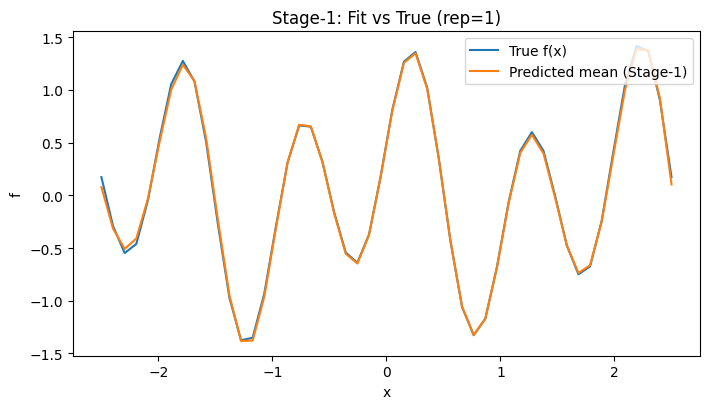

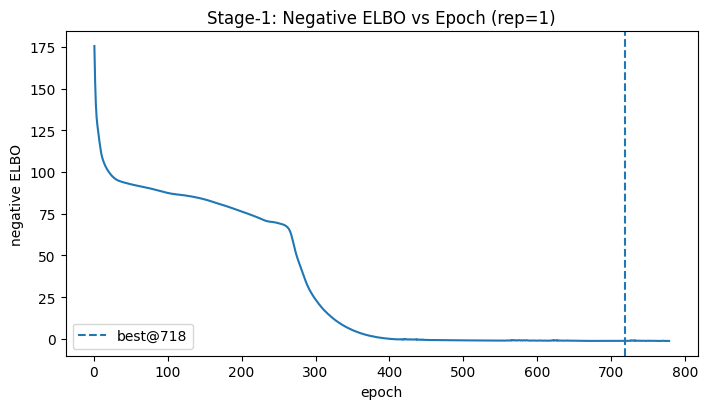

[18:14:16] [rep 001/100] α=1.000 (Stage-2) | best -ELBO=-1.370615 @epoch 1323 | MSE=0.000736
[18:14:16] [Checker] α=1.000: fraction(|bias|>band)=0.360; worst@x≈-2.500


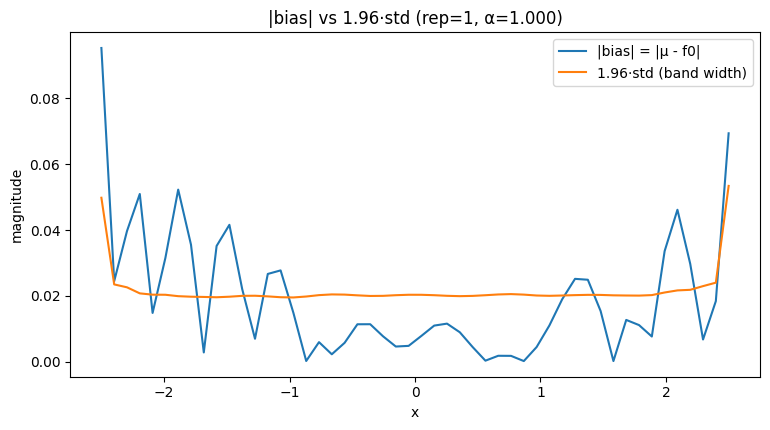

[18:14:36] [rep 001/100] α=0.800 (Stage-2) | best -ELBO=-1.303415 @epoch 1107 | MSE=0.000736
[18:15:00] [rep 001/100] α=0.600 (Stage-2) | best -ELBO=-1.192983 @epoch 1472 | MSE=0.000736
[18:15:24] [rep 001/100] α=0.500 (Stage-2) | best -ELBO=-1.106644 @epoch 1402 | MSE=0.000736
[18:15:24] [Checker] α=0.500: fraction(|bias|>band)=0.260; worst@x≈-2.500


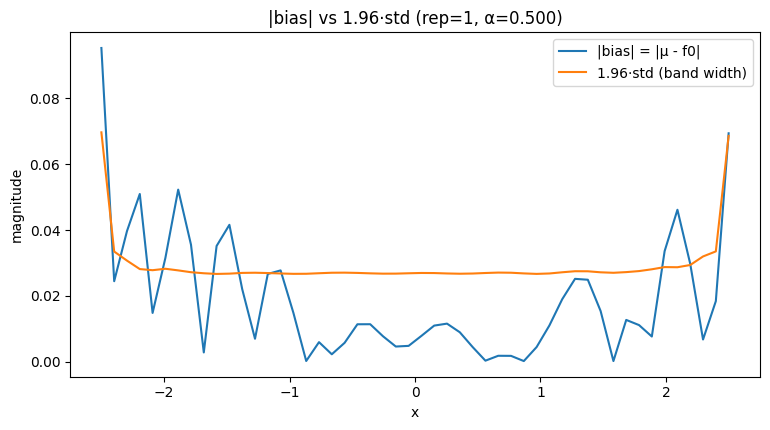

[18:15:49] [rep 001/100] α=0.300 (Stage-2) | best -ELBO=-0.766081 @epoch 1414 | MSE=0.000736
[18:16:13] [rep 001/100] α=0.100 (Stage-2) | best -ELBO=0.844158 @epoch 1485 | MSE=0.000736
[18:16:13] [Checker] α=0.100: fraction(|bias|>band)=0.000; worst@x≈-1.888


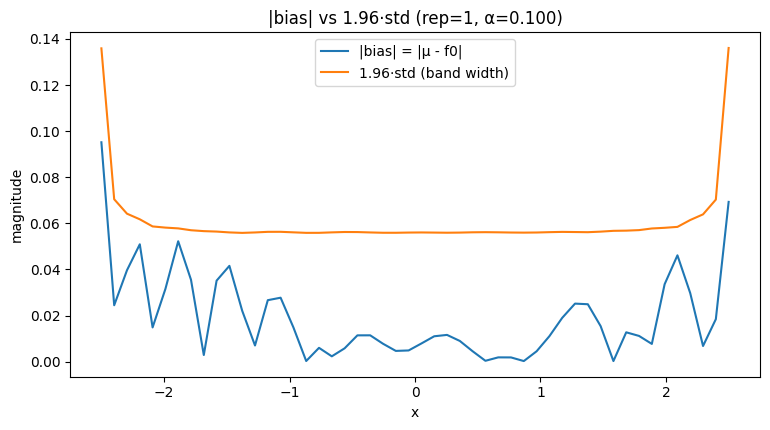

[18:16:37] [rep 001/100] α=0.001 (Stage-2) | best -ELBO=189.784061 @epoch 1066 | MSE=0.000736
[18:16:56] [rep 002/100] Stage-1 (α=1.000) | best -ELBO=-1.470139 @epoch 963 | MSE=0.000076
[18:17:20] [rep 002/100] α=1.000 (Stage-2) | best -ELBO=-1.478379 @epoch 1205 | MSE=0.000076
[18:17:45] [rep 002/100] α=0.800 (Stage-2) | best -ELBO=-1.417221 @epoch 1237 | MSE=0.000076
[18:18:10] [rep 002/100] α=0.600 (Stage-2) | best -ELBO=-1.317281 @epoch 1074 | MSE=0.000076
[18:18:34] [rep 002/100] α=0.500 (Stage-2) | best -ELBO=-1.239113 @epoch 1193 | MSE=0.000076
[18:18:59] [rep 002/100] α=0.300 (Stage-2) | best -ELBO=-0.932736 @epoch 859 | MSE=0.000076
[18:19:24] [rep 002/100] α=0.100 (Stage-2) | best -ELBO=0.507564 @epoch 946 | MSE=0.000076
[18:19:49] [rep 002/100] α=0.001 (Stage-2) | best -ELBO=163.197611 @epoch 1167 | MSE=0.000076
[18:20:08] [rep 003/100] Stage-1 (α=1.000) | best -ELBO=-1.472419 @epoch 965 | MSE=0.000071
[18:20:32] [rep 003/100] α=1.000 (Stage-2) | best -ELBO=-1.478712 @epoch 

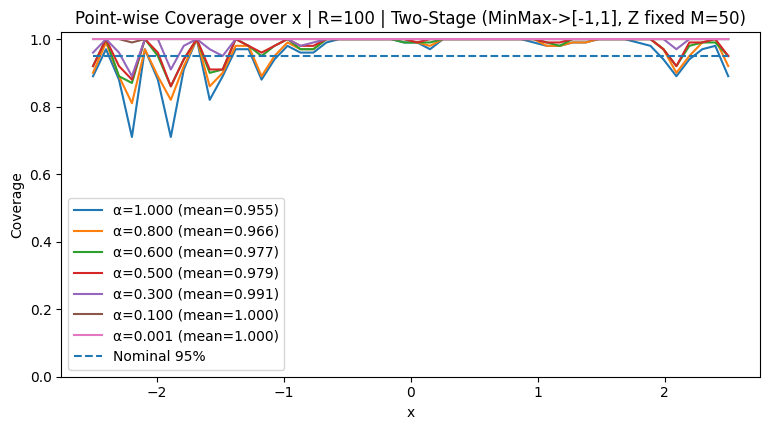

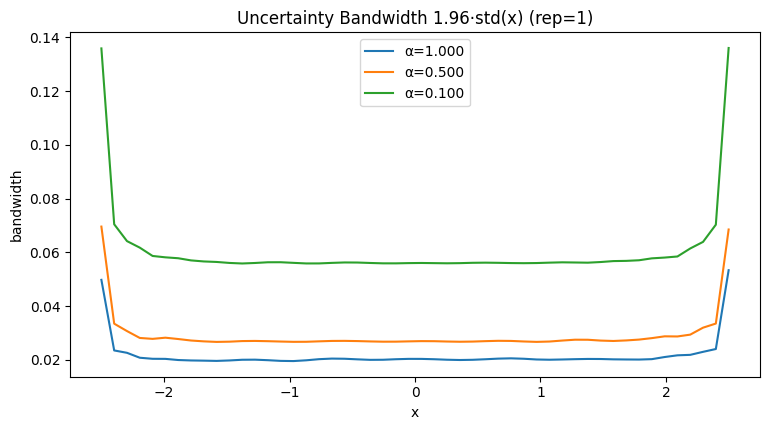

[01:23:16] Saved health summary to health_summary.csv
[01:23:16] 
=== Health summary (head) ===
[01:23:16]  alpha  mean_coverage  mse_mean   mse_sd  neg_elbo_mean  neg_elbo_sd  lengthscale_mean  lengthscale_sd  outputscale_mean  outputscale_sd  avg_bandwidth_mean  avg_bandwidth_sd  frac_tiny_std_mean
   1.0         0.9548  0.000145 0.000169      -1.465050     0.028785          0.193253        0.000979          2.681537        0.069796            0.022327          0.000993                 0.0
   0.8         0.9664  0.000145 0.000169      -1.403070     0.030839          0.193253        0.000979          2.681537        0.069796            0.024523          0.001001                 0.0
   0.6         0.9766  0.000145 0.000169      -1.301556     0.034300          0.193253        0.000979          2.681537        0.069796            0.027412          0.000617                 0.0
   0.5         0.9794  0.000145 0.000169      -1.221551     0.037068          0.193253        0.000979          2

In [1]:
# svgp_ciq_regression_alpha_suite_twostage_minmax_yzscore_plus.py
# Two-stage SVGP (latent-f only) with A1 INPUT NORMALIZATION (mentor-style):
#   x01 = (x_raw - train_low) / (train_high - train_low)   in [0,1]
#   x_std = 2*x01 - 1                                     in [-1,1]
# Train/test/Z share the SAME global transform. Z: M=50, fixed & not learnable.
#
# NEW (your request):
#   - y_train is standardized (Z-score) BEFORE training (still noiseless latent f0; no observed-y used)
#   - Predictions are de-standardized back to RAW y space for MSE/coverage/plots/diagnostics
#
# Stage-1 (alpha=1): train kernel + variational mean (noise fixed; Z fixed).
# Stage-2 (alphas): reload Stage-1, train ONLY variational covariance with beta=1/alpha.
# Extras retained:
#   (1) Heatmaps for alphas in {1.0, 0.5, 0.1}
#   (2) Extra diagnostics: standardized residual QQ plot (rep=1)
#   (3) Uncertainty bandwidth plot (rep=1, three alphas)
#   (4) Health summary table per alpha (CSV)

import math, time
from contextlib import ExitStack
from dataclasses import dataclass

import torch, gpytorch
import numpy as np
import pandas as pd
from torch.utils.data import DataLoader, TensorDataset
import matplotlib.pyplot as plt

# ---------------- logging ----------------
def now(): return time.strftime("%H:%M:%S")
def log(msg): print(f"[{now()}] {msg}", flush=True)
def gpu_mem_mb(): return (torch.cuda.memory_allocated()/1e6) if torch.cuda.is_available() else 0.0

# ---------------- helpers ----------------
def has_setting(name: str) -> bool: return hasattr(gpytorch.settings, name)

def ciq_context():
    stack = ExitStack()
    for name, val in [
        ("num_contour_quadrature", 15),
        ("ciq_samples", 16),
        ("ciq_max_iter", 30),
        ("ciq_forward_precision", 0.01),
        ("eval_cg_tolerance", 1e-4),
        ("max_root_decomposition_size", 64),
    ]:
        if has_setting(name):
            stack.enter_context(getattr(gpytorch.settings, name)(val))
    stack.enter_context(gpytorch.settings.fast_pred_var(True))
    return stack

def clone_state_dict(sd):
    out = {}
    for k, v in sd.items():
        out[k] = v.detach().clone() if torch.is_tensor(v) else v
    return out

# true latent f (noiseless)
def f0(x: torch.Tensor) -> torch.Tensor:
    return torch.sin(2 * math.pi * x) + 0.5 * torch.cos(3 * x)

# 1D stratified (LHS-like) points — used ONCE globally
def make_stratified_points_1d(n, low, high, generator, device, dtype):
    i = torch.arange(n, device=device, dtype=dtype)
    u = (i + torch.rand(n, generator=generator, device=device, dtype=dtype)) / n
    x = low + (high - low) * u
    perm = torch.randperm(n, generator=generator, device=device)
    return x[perm].unsqueeze(-1)

# ---------------- config ----------------
@dataclass
class CFG:
    # data
    n_train: int = 500
    n_test: int = 50
    train_low: float = -2.5
    train_high: float = 2.5
    test_low: float = -2.5
    test_high: float = 2.5

    # model/train
    use_fp64: bool = True
    use_ciq: bool = False
    inducing_points: int = 50
    stage1_epochs: int = 5000
    stage2_epochs: int = 1500
    batch_size: int = 500
    lr_adam_stage1: float = 2e-2
    lr_adam_stage2: float = 2e-2
    jitter: float = 1e-2
    seed: int = 13

    # likelihood (still used as a nugget for VI stability; latent-f setting)
    noise_raw: float = 3e-3   # interpreted as nugget level in RAW y units (before y-standardization)

    # early stopping
    early_stop_patience: int = 60
    early_stop_min_delta: float = 1e-4

    # experiment
    alphas: tuple = (1.0, 0.8, 0.6, 0.5, 0.3, 0.1, 0.001)
    replications: int = 100

    # logging/plots
    log_epoch: bool = False
    log_every: int = 10
    show_plots: bool = True
    save_plots: bool = True

    # extras
    heatmap_alphas: tuple = (1.0, 0.5, 0.1)   # which alphas to heatmap/diagnose

# ---------------- model ----------------
class SVGPModel(gpytorch.models.ApproximateGP):
    def __init__(self, inducing_points_std: torch.Tensor):
        M = inducing_points_std.size(0)
        q_dist = gpytorch.variational.CholeskyVariationalDistribution(M)
        q_strat = gpytorch.variational.VariationalStrategy(
            self, inducing_points_std, q_dist, learn_inducing_locations=False
        )
        super().__init__(q_strat)
        self.mean_module = gpytorch.means.ConstantMean()
        self.covar_module = gpytorch.kernels.ScaleKernel(gpytorch.kernels.RBFKernel())

    def forward(self, x_std):
        mean_x = self.mean_module(x_std)
        covar_x = self.covar_module(x_std)
        return gpytorch.distributions.MultivariateNormal(mean_x, covar_x)

# ---------------- two-stage param helpers ----------------
def freeze_all_params(model, likelihood):
    for p in model.parameters(): p.requires_grad_(False)
    for p in likelihood.parameters(): p.requires_grad_(False)

def pick_covariance_params_svgp(model):
    """Select ONLY variational covariance parameters (exclude any '*mean*')."""
    trainables, names = [], []
    vdist_mod = None
    vs = getattr(model, "variational_strategy", None)
    if vs is not None:
        if hasattr(vs, "_variational_distribution"):
            vdist_mod = getattr(vs, "_variational_distribution")
        else:
            cand = getattr(vs, "variational_distribution", None)
            if isinstance(cand, torch.nn.Module):
                vdist_mod = cand
    if isinstance(vdist_mod, torch.nn.Module):
        for n, p in vdist_mod.named_parameters(recurse=True):
            low = n.lower()
            if "mean" in low:
                p.requires_grad_(False)
            elif any(k in low for k in ["chol", "std", "var", "covar", "factor"]):
                p.requires_grad_(True); trainables.append(p); names.append(f"vdist.{n}")
            else:
                p.requires_grad_(False)
    if not trainables:
        allow = (
            "chol_variational_covar","variational_distribution.chol_covar",
            "variational_distribution._cholesky_factor","_variational_distribution.chol_covar",
            "raw_covar","chol_factor","covar_factor","variational_stddev","raw_var",
            "qchol","q_scale_tril"
        )
        for n, p in model.named_parameters():
            low = n.lower()
            if "variational_strategy" in low and any(k in low for k in allow) and "mean" not in low:
                p.requires_grad_(True); trainables.append(p); names.append(n)
    return trainables, names

# ---------------- Stage-1 ----------------
def stage1_train(model, likelihood, x_train_std, y_train_std, lr, epochs, jitter, batch_size,
                 early_stop_patience, early_stop_min_delta, log_epoch=False, log_every=10):
    N = x_train_std.size(0)
    mll = gpytorch.mlls.VariationalELBO(likelihood, model, num_data=N, beta=1.0)

    likelihood.noise_covar.raw_noise.requires_grad_(False)
    opt = torch.optim.Adam([
        {"params": model.variational_parameters()},
        {"params": model.hyperparameters()},
        {"params": likelihood.parameters()},
    ], lr=lr)

    loader = DataLoader(TensorDataset(x_train_std, y_train_std),
                        batch_size=batch_size, shuffle=True, drop_last=False)

    model.train(); likelihood.train()
    neg_elbo_hist, best_loss, best_epoch = [], float("inf"), 0
    best_model_sd = clone_state_dict(model.state_dict())
    best_lik_sd   = clone_state_dict(likelihood.state_dict())
    patience = 0

    with gpytorch.settings.cholesky_jitter(jitter):
        for ep in range(1, epochs + 1):
            total, n_batches = 0.0, 0
            for xb, yb in loader:
                opt.zero_grad(set_to_none=True)
                out = model(xb)
                loss = -mll(out, yb)
                if loss.numel() > 1: loss = loss.mean()
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), 5.0)
                opt.step()
                total += float(loss.item()); n_batches += 1
            avg_loss = total / max(1, n_batches)
            neg_elbo_hist.append(avg_loss)

            if best_loss - avg_loss > early_stop_min_delta:
                best_loss, best_epoch = avg_loss, ep
                best_model_sd = clone_state_dict(model.state_dict())
                best_lik_sd   = clone_state_dict(likelihood.state_dict())
                patience = 0
            else:
                patience += 1

            if log_epoch and (ep % log_every == 0 or ep == 1 or ep == epochs):
                log(f"[S1] epoch {ep:04d}/{epochs} | -ELBO={avg_loss:.6f} (best {best_loss:.6f}@{best_epoch})")

            if patience >= early_stop_patience: break

    model.load_state_dict(best_model_sd)
    likelihood.load_state_dict(best_lik_sd)
    model.eval(); likelihood.eval()
    return neg_elbo_hist, best_epoch, best_loss

# ---------------- Stage-2 ----------------
def stage2_train_cov_only(model, likelihood, x_train_std, y_train_std, beta, lr, epochs, jitter, batch_size):
    N = x_train_std.size(0)
    freeze_all_params(model, likelihood)
    cov_params, cov_names = pick_covariance_params_svgp(model)
    assert cov_params, "No covariance params found to train in Stage-2."
    mll = gpytorch.mlls.VariationalELBO(likelihood, model, num_data=N, beta=beta)
    opt = torch.optim.Adam(cov_params, lr=lr)

    loader = DataLoader(TensorDataset(x_train_std, y_train_std),
                        batch_size=batch_size, shuffle=True, drop_last=False)

    model.train(); likelihood.train()
    neg_elbo_hist, best_loss, best_epoch = [], float("inf"), 0
    best_model_sd = clone_state_dict(model.state_dict())
    best_lik_sd   = clone_state_dict(likelihood.state_dict())

    with gpytorch.settings.cholesky_jitter(jitter):
        for ep in range(1, epochs + 1):
            total, n_batches = 0.0, 0
            for xb, yb in loader:
                opt.zero_grad(set_to_none=True)
                out = model(xb)
                loss = -mll(out, yb)
                if loss.numel() > 1: loss = loss.mean()
                loss.backward()
                torch.nn.utils.clip_grad_norm_(cov_params, 5.0)
                opt.step()
                total += float(loss.item()); n_batches += 1
            avg_loss = total / max(1, n_batches)
            neg_elbo_hist.append(avg_loss)
            if avg_loss < best_loss:
                best_loss, best_epoch = avg_loss, ep
                best_model_sd = clone_state_dict(model.state_dict())
                best_lik_sd   = clone_state_dict(likelihood.state_dict())

    model.load_state_dict(best_model_sd)
    likelihood.load_state_dict(best_lik_sd)
    model.eval(); likelihood.eval()
    return neg_elbo_hist, best_epoch, best_loss, cov_names

# ---------------- plotting helpers ----------------
def plot_heatmap(ind_mat, x_axis, alpha, out_prefix="heatmap", vmin=0.0, vmax=1.0):
    """ind_mat: [R,J] 0/1 coverage matrix for a given alpha"""
    plt.figure(figsize=(9, 4.8))
    plt.imshow(ind_mat, aspect="auto", interpolation="nearest",
               vmin=vmin, vmax=vmax, extent=[x_axis.min(), x_axis.max(), ind_mat.shape[0], 0])
    plt.colorbar(label="coverage (0/1)")
    plt.xlabel("x")
    plt.ylabel("replication")
    plt.title(f"Coverage Heatmap (α={alpha:.3f})  — rows: reps, cols: x-grid")
    plt.tight_layout()
    plt.savefig(f"{out_prefix}_alpha{alpha:.3f}.png", dpi=150)
    plt.close()

def qq_plot(z, alpha, out_prefix="qqplot"):
    """Standard normal QQ plot without external deps."""
    z = np.asarray(z)
    z = z[np.isfinite(z)]
    z_sorted = np.sort(z)
    n = z_sorted.size
    if n == 0:
        return
    p = (np.arange(1, n+1) - 0.5) / n
    q_theory = np.sqrt(2) * torch.erfinv(torch.tensor(2*p - 1)).numpy()
    plt.figure(figsize=(5.6, 5.2))
    plt.plot(q_theory, z_sorted, ".", markersize=3)
    lim = float(np.nanmax(np.abs(np.concatenate([q_theory, z_sorted]))))
    lim = max(lim, 3.0)
    plt.plot([-lim, lim], [-lim, lim], "k--", linewidth=1)
    plt.xlabel("Theoretical quantiles  N(0,1)")
    plt.ylabel("Sample quantiles of z")
    plt.title(f"QQ plot of standardized residuals (rep=1, α={alpha:.3f})")
    plt.tight_layout()
    plt.savefig(f"{out_prefix}_alpha{alpha:.3f}.png", dpi=150)
    plt.close()

# ---------------- main ----------------
def main():
    cfg = CFG()
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    torch.set_default_dtype(torch.float64 if cfg.use_fp64 else torch.float32)

    # seeds
    torch.manual_seed(cfg.seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(cfg.seed)

    log(f"Device: {device} | dtype: {torch.get_default_dtype()}")
    if torch.cuda.is_available(): log(f"CUDA mem (start): {gpu_mem_mb():.0f} MB")

    # ---- GLOBAL fixed train/test (RAW) ----
    gen = torch.Generator(device=device).manual_seed(cfg.seed)
    x_train_raw = make_stratified_points_1d(
        n=cfg.n_train, low=cfg.train_low, high=cfg.train_high,
        generator=gen, device=device, dtype=torch.get_default_dtype()
    )
    x_test_raw = torch.linspace(cfg.test_low, cfg.test_high, cfg.n_test,
                                device=device, dtype=torch.get_default_dtype()).unsqueeze(1)

    # latent noiseless targets
    y_train_raw = f0(x_train_raw).squeeze(-1)
    y_test_true_raw = f0(x_test_raw).squeeze(-1)

    # ---- A1 INPUT NORMALIZATION (mentor-style): min-max -> [0,1], then -> [-1,1] ----
    train_low = torch.as_tensor(cfg.train_low, device=device, dtype=torch.get_default_dtype())
    train_high = torch.as_tensor(cfg.train_high, device=device, dtype=torch.get_default_dtype())
    span = (train_high - train_low).clamp_min(1e-12)

    def x_to_std(x_raw):
        x01 = (x_raw - train_low) / span
        return 2.0 * x01 - 1.0

    x_train_std = x_to_std(x_train_raw)
    x_test_std  = x_to_std(x_test_raw)

    Z_raw = torch.linspace(cfg.train_low, cfg.train_high, cfg.inducing_points,
                           device=device, dtype=torch.get_default_dtype()).unsqueeze(1)
    Z_std = x_to_std(Z_raw)

    # quick sanity (match prior prints, but adapted)
    left_std = float(x_to_std(torch.tensor([[cfg.train_low]], device=device, dtype=torch.get_default_dtype())))
    right_std = float(x_to_std(torch.tensor([[cfg.train_high]], device=device, dtype=torch.get_default_dtype())))
    log(f"MinMax norm: raw [{cfg.train_low:.2f},{cfg.train_high:.2f}] -> std [{left_std:.2f},{right_std:.2f}] (≈ -1,+1)")
    log(f"Z_std head/tail: {float(Z_std[0]):.3f}, {float(Z_std[-1]):.3f}")

    # ---- storage (coverage & health) ----
    alphas = list(cfg.alphas)
    A, R, J = len(alphas), cfg.replications, cfg.n_test
    indicators = np.zeros((A, R, J), dtype=np.float64)

    mse_mat = np.zeros((A, R))
    elbo_mat = np.zeros((A, R))
    ls_mat = np.zeros((A, R))
    os_mat = np.zeros((A, R))
    avg_bandwidth_mat = np.zeros((A, R))
    frac_tiny_std_mat = np.zeros((A, R))

    rep_to_plot = 0

    # for bandwidth overlay at rep=1
    band_curves_rep1 = {}

    for r in range(R):
        # ---- Y STANDARDIZATION (Z-score) ----
        # (data are noiseless latent-f; this is purely a training/conditioning transform)
        y_mean = y_train_raw.mean()
        y_std = y_train_raw.std(unbiased=False).clamp_min(1e-12)
        y_train_std = (y_train_raw - y_mean) / y_std

        # build model/likelihood fresh with fixed Z_std
        model = SVGPModel(Z_std.clone().contiguous()).to(device=device)
        likelihood = gpytorch.likelihoods.GaussianLikelihood().to(device=device)

        # initialize hypers + set nugget/noise in STANDARDIZED y space
        with torch.no_grad():
            model.covar_module.base_kernel.lengthscale.fill_(1.0)
            model.covar_module.outputscale.fill_(1.0)
            # noise_raw is in RAW y units; convert to standardized units
            likelihood.noise = torch.as_tensor(cfg.noise_raw, device=device, dtype=torch.get_default_dtype()) / (y_std ** 2)

        likelihood.noise_covar.raw_noise.requires_grad_(False)

        # ---- Stage-1 (alpha=1) ----
        with (ciq_context() if cfg.use_ciq else ExitStack()):
            neg_elbo_hist_s1, best_epoch_s1, best_loss_s1 = stage1_train(
                model, likelihood, x_train_std, y_train_std,
                lr=cfg.lr_adam_stage1, epochs=cfg.stage1_epochs, jitter=cfg.jitter,
                batch_size=cfg.batch_size,
                early_stop_patience=cfg.early_stop_patience,
                early_stop_min_delta=cfg.early_stop_min_delta,
                log_epoch=cfg.log_epoch, log_every=cfg.log_every
            )

        with torch.no_grad():
            pred_f_std = model(x_test_std)
            mu_std = pred_f_std.mean
            # de-standardize mean to RAW for MSE and plots
            mu_raw = mu_std * y_std + y_mean
            mse_s1 = torch.mean((mu_raw - y_test_true_raw) ** 2).item()

        log(f"[rep {r+1:03d}/{R}] Stage-1 (α=1.000) | best -ELBO={best_loss_s1:.6f} @epoch {best_epoch_s1} | MSE={mse_s1:.6f}")

        if r == rep_to_plot:
            # Fit vs True (RAW space)
            plt.figure(figsize=(7.2, 4.2))
            plt.plot(x_test_raw.squeeze(-1).cpu(), y_test_true_raw.cpu().numpy(), label="True f(x)")
            plt.plot(x_test_raw.squeeze(-1).cpu(), mu_raw.cpu().numpy(), label="Predicted mean (Stage-1)")
            plt.title(f"Stage-1: Fit vs True (rep={r+1})")
            plt.xlabel("x"); plt.ylabel("f"); plt.legend(); plt.tight_layout()
            if cfg.save_plots: plt.savefig(f"stage1_fit_vs_true_rep{r+1}_minmax_yz.png", dpi=150)
            if cfg.show_plots: plt.show()
            else: plt.close()

            # -ELBO curve
            plt.figure(figsize=(7.2, 4.2))
            plt.plot(range(1, len(neg_elbo_hist_s1) + 1), neg_elbo_hist_s1)
            plt.axvline(best_epoch_s1, linestyle="--", label=f"best@{best_epoch_s1}")
            plt.title(f"Stage-1: Negative ELBO vs Epoch (rep={r+1})")
            plt.xlabel("epoch"); plt.ylabel("negative ELBO"); plt.legend(); plt.tight_layout()
            if cfg.save_plots: plt.savefig(f"stage1_neg_elbo_rep{r+1}_minmax_yz.png", dpi=150)
            if cfg.show_plots: plt.show()
            else: plt.close()

        # checkpoint after Stage-1
        s1_model_sd = clone_state_dict(model.state_dict())
        s1_lik_sd   = clone_state_dict(likelihood.state_dict())

        # ---- Stage-2 across alphas ----
        for a_idx, alpha in enumerate(alphas):
            beta = 1.0 / alpha
            model.load_state_dict(s1_model_sd)
            likelihood.load_state_dict(s1_lik_sd)
            model.eval(); likelihood.eval()

            with (ciq_context() if cfg.use_ciq else ExitStack()):
                neg_elbo_hist_s2, best_epoch_s2, best_loss_s2, cov_names = stage2_train_cov_only(
                    model, likelihood, x_train_std, y_train_std,
                    beta=beta, lr=cfg.lr_adam_stage2, epochs=cfg.stage2_epochs,
                    jitter=cfg.jitter, batch_size=cfg.batch_size
                )

            with torch.no_grad():
                pred_f_std = model(x_test_std)
                mu_std = pred_f_std.mean
                var_std = pred_f_std.variance.clamp_min(1e-24)

                # de-standardize to RAW for coverage/MSE/diagnostics
                mu_raw = mu_std * y_std + y_mean
                var_raw = var_std * (y_std ** 2)
                std_raw = var_raw.sqrt().clamp_min(1e-12)

                lower, upper = mu_raw - 1.96 * std_raw, mu_raw + 1.96 * std_raw
                cover = ((y_test_true_raw >= lower) & (y_test_true_raw <= upper)).to(torch.float64)
                indicators[a_idx, r, :] = cover.cpu().numpy()

                mse = torch.mean((mu_raw - y_test_true_raw) ** 2).item()

                # health stats (hypers are in x_std space; keep as-is)
                ls = float(model.covar_module.base_kernel.lengthscale.mean())
                os = float(model.covar_module.outputscale)
                elbo_mat[a_idx, r] = float(best_loss_s2)
                mse_mat[a_idx, r] = float(mse)
                ls_mat[a_idx, r] = ls
                os_mat[a_idx, r] = os
                avg_bandwidth_mat[a_idx, r] = float((1.96 * std_raw).mean().item())
                frac_tiny_std_mat[a_idx, r] = float((std_raw < 1e-9).to(torch.float32).mean().item())

                if r == rep_to_plot and (alpha in cfg.heatmap_alphas):
                    band_curves_rep1[alpha] = (
                        x_test_raw.squeeze(-1).cpu().numpy(),
                        (1.96 * std_raw).cpu().numpy()
                    )

            log(f"[rep {r+1:03d}/{R}] α={alpha:.3f} (Stage-2) | best -ELBO={best_loss_s2:.6f} @epoch {best_epoch_s2} | MSE={mse:.6f}")

            # ---- Extra diagnostics at rep=1 for chosen alphas ----
            if r == rep_to_plot and (alpha in cfg.heatmap_alphas):
                # |bias| vs band (RAW)
                abs_bias = (mu_raw - y_test_true_raw).abs()
                band = 1.96 * std_raw
                frac_viol = float((abs_bias > band).to(torch.float32).mean())
                worst_idx = int(torch.argmax(abs_bias - band).item())
                x_worst = float(x_test_raw[worst_idx])
                log(f"[Checker] α={alpha:.3f}: fraction(|bias|>band)={frac_viol:.3f}; worst@x≈{x_worst:.3f}")

                xs = x_test_raw.squeeze(-1).cpu().numpy()
                plt.figure(figsize=(7.8, 4.4))
                plt.plot(xs, abs_bias.cpu().numpy(), label="|bias| = |μ - f0|")
                plt.plot(xs, band.cpu().numpy(), label="1.96·std (band width)")
                plt.title(f"|bias| vs 1.96·std (rep=1, α={alpha:.3f})")
                plt.xlabel("x"); plt.ylabel("magnitude"); plt.legend(); plt.tight_layout()
                if cfg.save_plots: plt.savefig(f"checker_bias_vs_band_rep1_alpha{alpha:.3f}_minmax_yz.png", dpi=150)
                if cfg.show_plots: plt.show()
                else: plt.close()

                # standardized residual QQ plot (RAW residual / RAW std)
                z = ((y_test_true_raw - mu_raw) / std_raw).cpu().numpy()
                qq_plot(z, alpha, out_prefix="qqplot_rep1_minmax_yz")

    # ---- coverage curves（整体） ----
    x_axis = x_test_raw.squeeze(-1).cpu().numpy()
    coverage_curves = indicators.mean(axis=1)   # [A, J]
    overall_cov = coverage_curves.mean(axis=1)  # [A]

    plt.figure(figsize=(7.8, 4.4))
    for a_idx, alpha in enumerate(alphas):
        plt.plot(x_axis, coverage_curves[a_idx], label=f"α={alpha:.3f} (mean={overall_cov[a_idx]:.3f})")
    plt.hlines(0.95, x_axis.min(), x_axis.max(), linestyles="--", label="Nominal 95%")
    plt.ylim(0.0, 1.02)
    plt.title(f"Point-wise Coverage over x | R={cfg.replications} | Two-Stage (MinMax->[-1,1], Z fixed M={cfg.inducing_points})")
    plt.xlabel("x"); plt.ylabel("Coverage"); plt.legend(); plt.tight_layout()
    if cfg.save_plots: plt.savefig(f"coverage_curves_R{cfg.replications}_twostage_minmax_yz.png", dpi=150)
    if cfg.show_plots: plt.show()
    else: plt.close()

    # ---- (1) Heatmaps for selected alphas ----
    for a_sel in cfg.heatmap_alphas:
        if a_sel in alphas:
            idx = alphas.index(a_sel)
            plot_heatmap(indicators[idx], x_axis, a_sel,
                         out_prefix=f"coverage_heatmap_R{cfg.replications}_minmax_yz")

    # ---- (3) Uncertainty bandwidth overlay (rep=1) for selected alphas ----
    if band_curves_rep1:
        plt.figure(figsize=(7.8, 4.4))
        for a_sel in cfg.heatmap_alphas:
            if a_sel in band_curves_rep1:
                xs, band = band_curves_rep1[a_sel]
                plt.plot(xs, band, label=f"α={a_sel:.3f}")
        plt.title("Uncertainty Bandwidth 1.96·std(x) (rep=1)")
        plt.xlabel("x"); plt.ylabel("bandwidth")
        plt.legend(); plt.tight_layout()
        if cfg.save_plots: plt.savefig("bandwidth_overlay_rep1_minmax_yz.png", dpi=150)
        if cfg.show_plots: plt.show()
        else: plt.close()

    # ---- (4) Health summary table per alpha ----
    rows = []
    for a_idx, alpha in enumerate(alphas):
        row = {
            "alpha": alpha,
            "mean_coverage": float(overall_cov[a_idx]),
            "mse_mean": float(np.mean(mse_mat[a_idx])),
            "mse_sd": float(np.std(mse_mat[a_idx])),
            "neg_elbo_mean": float(np.mean(elbo_mat[a_idx])),
            "neg_elbo_sd": float(np.std(elbo_mat[a_idx])),
            "lengthscale_mean": float(np.mean(ls_mat[a_idx])),
            "lengthscale_sd": float(np.std(ls_mat[a_idx])),
            "outputscale_mean": float(np.mean(os_mat[a_idx])),
            "outputscale_sd": float(np.std(os_mat[a_idx])),
            "avg_bandwidth_mean": float(np.mean(avg_bandwidth_mat[a_idx])),
            "avg_bandwidth_sd": float(np.std(avg_bandwidth_mat[a_idx])),
            "frac_tiny_std_mean": float(np.mean(frac_tiny_std_mat[a_idx])),
        }
        rows.append(row)
    df = pd.DataFrame(rows)
    df = df[[
        "alpha","mean_coverage",
        "mse_mean","mse_sd",
        "neg_elbo_mean","neg_elbo_sd",
        "lengthscale_mean","lengthscale_sd",
        "outputscale_mean","outputscale_sd",
        "avg_bandwidth_mean","avg_bandwidth_sd",
        "frac_tiny_std_mean"
    ]]
    df.to_csv("health_summary.csv", index=False)
    log("Saved health summary to health_summary.csv")
    log("\n=== Health summary (head) ===")
    log(df.head().to_string(index=False))

    # ---- Save indicators for reproducibility ----
    np.save("indicator_matrix_twostage_minmax_yz.npy", indicators)
    log(f"Saved indicator matrix with shape {indicators.shape} to indicator_matrix_twostage_minmax_yz.npy")

if __name__ == "__main__":
    main()
